## Formatting for Plots
### (IGNORE THIS IF YOU ARE A GENERAL USER)

In [4]:
import sys
import pandas as pd
from pathlib import Path
root = Path().resolve()
src_path = root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from analysislib import formatting
from analysislib import graphs
formatting.format_notebook()

from analysislib import sdss
sdss.setup(pd.read_csv("data/SDSS_500k_v7.csv"))

---

## Part 4 — Distances, Sizes, and Luminosities

---

<div style="width: 750px;
            display: inline-block;
            margin-right: 50px">

So far, we have described galaxies by their *appearance*: colour, concentration and profile shape. But appearance depends on distance in ways that can deceive us: a faint red smudge in the sky might be a small nearby dwarf galaxy, or an enormous elliptical billions of light-years away. We don't know. So to understand what galaxies actually *are*, we need to know how far away they are.

Fortunately, we already have a distance proxy* in our dataset: **redshift**. In this notebook, we're going to use redshift to convert apparent measurements into physical ones. We'll compute luminosity, distances, absolute magnitudes, and physical sizes, and explore how these intrinsic properties relate to the evolutionary state of galaxies.

This directly addresses our central question: *what drives galaxy transformation?* By placing galaxies in space and time, we can begin to see whether the evolutionary patterns we found in colour and structure depend on how massive a galaxy is, and whether we can glimpse how those patterns change across cosmic time.

<br>

</div>

<div style="width: 400px;
            display: inline-block">
<img src="images/pinwheel.jpg"></img>
<center>
<i>Pinwheel Galaxy. Credit: Wikipedia</i>
</center>
</div>

<div style="width: 1200px">

**In the context of astronomy, a **proxy** is an indirect indicator used to infer some other property. In this example, redshift is a proxy for distance, because it indirectly encodes distance in its measurement.*

</div>

---

### The Expanding Universe

---

<div style="width: 1200px">

Before we can measure how far away a galaxy is, we need to understand something very important about the universe: **it's expanding**.

This isn't a trivial statement. It doesn't mean that galaxies are flying outward through empty space like shrapnel from an explosion. It means that the **space itself is stretching**. Two galaxies that are not gravitationally bound to each other will find themselves further apart tomorrow than they are today because the space between them will grow.

This was first observed by Edwin Hubble in 1929. He noticed that almost every galaxy he measured had its light shifted toward the red end of the spectrum. But more importantly, the further away a galaxy was, the more redshifted it was. This is all quite confusing, but basically galaxies are being carried apart by an expanding universe, and more distant galaxies are receding faster because there is more expanding space between us and them.

This relationship of **recession speed proportional to distance** is Hubble's Law:

$$v = H_0 \times d$$

where $v$ is the recession speed, $d$ is the distance, and $H_0$ is the **Hubble constant**, which is the current rate of expansion of the universe measured in kilometres per second per megaparsec.

This is a super weird unit: it's distance per time per some other distance. But the way you should think about it is by breaking it up into the "kilometres per second" part, and the "per megaparsec" part. "Kilometres per second" is obviously a unit of speed: sound travels at about 0.3 kilometres per second, and an airbus A320 flies at about 0.25 kilometres per second. So, the unit essentially becomes "speed per distance", reflecting how the apparent rate of expansion of the universe depends on it's distance.

The best current value of the hubble constant is roughly 70 km/s/Mpc, meaning that a galaxy 1 megaparsec away recedes at ~70 km/s, a galaxy 10 Mpc away recedes at ~700 km/s, and so on. It's important to note that we don't actually know what the hubble constant is (it probably varies), and 70 km/s/Mpc is just a rough average of what we have observed.

</div>

<div style="width: 1200px">
<center>
<img src="images/expansion.png" width="750px"></img>

<i>Credit: Nicole Granucci</i>
</center>
</div>

---

### Dark Matter and Dark Energy

---

<div style="width: 1200px">

The next thing we need to understand is subtle but important: dark matter and dark energy.

<br>

> As a disclaimer, dark matter and dark energy are not "proven" to actually exist, but there is a whole heap of evidence pointing towards it, and our current best theories revolve around its existence.

<br>

So it turns out that the universe we can see: all the stars, galaxies, gas, and dust detected by every telescope ever built, makes up only about **5% of the total energy content of the universe**. The remaining 95% comes in two mysterious forms:

<br>

#### Dark Matter (~27%)

<div style="width: 750px;
            display: inline-block;
            margin-right: 50px">

Dark matter is matter that doesn't interact with light: it neither emits nor absorbs nor reflects photons of any kind. We can't see it directly, and we can only infer its presence from its gravitational effects.

Many galaxies, including our own Milky Way, rotate way too fast for the amount of visible matter they contain, and without a large halo of invisible dark matter surrounding each galaxy, they would fly apart. Galaxy clusters also deflect light from background objects far more strongly than their visible mass alone
could explain. And the large-scale structure of the universe matches simulations remarkably well when dark matter is included, but fails completely without it.

Dark matter is crucial for galaxy formation. It provides the gravitational scaffolding into which ordinary gas falls and cools, eventually forming stars. Without dark matter, galaxies as we know them could not exist.

</div>

<div style="width: 400px;
            display: inline-block">
<img src="images/dark_matter.webp"></img>
<center>
<i>Simulation of Dark Matter. Credit: NASA</i>
</center>
</div>

#### Dark Energy (~68%)

<div style="width: 400px;
            display: inline-block;
            margin-right: 50px">
<img src="images/lambda_cdm.webp"></img>
<center>
<i>Credit: Big Think</i>
</center>
</div>

<div style="width: 750px;
            display: inline-block">

Dark energy is even stranger than dark matter. It's a form of energy that appears to be uniformly spread throughout space, and it doesn't dilute as the universe expands.

Now the reason that astronomers came up with dark energy in the first place is because of a paradox with the expansion of the universe. If dark energy didn't exist, then one might expect that gravity would gradually slow the expansion of the universe down, but in reality, something is pushing space apart faster and faster over time. The solution to this paradox is the existence of dark energy, whose role is to accelerate the expansion of the universe.

We don't know what dark energy fundamentally *is*. The simplest model treats it as a **cosmological constant** $\Lambda$, but there are hundreds of other interpretations. The cosmological constant was first introduced (and then famously abandoned) by Einstein in 1917.

</div>

---

### The $\Lambda\text{CDM}$ Model

---

<div style="width: 1200px">

When we put all these ingredients together, we finally get the standard model of cosmology: **$\Lambda\text{CDM}$** (Lambda Cold Dark Matter)

* **$\Lambda$** (Lambda) represents the cosmological constant, and dark energy
* **C** stands for Cold, and it describes how dark matter moves slowly relative to the speed of light, which allows it to clump together gravitationally to form the large-scale structures that we observe
* **DM** stands for Dark Matter

The $\Lambda\text{CDM}$ model describes a universe that is:

* **Flat**: the large-scale geometry of space has no curvature, and parallel lines stay parallel forever*
* **13.8 billion years old**: this is calculated by running the expansion backwards to the Big Bang
* **Homogeneous and isotropic on large scales**: the universe is roughly the same in every direction and every region, once you average out over massive scales

<br>

So, now that we have made it to defining the $\Lambda\text{CDM}$ model, we can define the parameters that will let us relate redshift with distances. The three key parameters that we'll use in this section are:

| Parameter | Symbol | Value | Meaning |
|-----------|--------|-------|---------|
| Hubble constant | $H_0$ | 70 km/s/Mpc | The current expansion rate of the universe |
| Matter density | $\Omega_m$ | 0.3 | The fraction of energy in the form of actual matter (both dark and ordinary) |
| Dark energy density | $\Omega_\Lambda$ | 0.7 | The fraction of energy in the form of dark energy |

<br>

**This is hinting towards something called Einstein's theory of General Relativity*

</div>

---

### Calculating Distance from Redshift

---

<div style="width: 1200px">

Okay, time to convert a galaxy's redshift into actual physical distance!!

<br>

> This section includes some hard-ish maths. If you have high school PTSD of maths, skip this section. If you don't understand the following maths, it's totally OK

<br>

The expansion rate of the universe changes over time: it was originally very fast, then gradually decreased up until around 9.8 billion years after the big bang, and is accelerating now as dark energy takes over. To describe this change, we can construct an equation which will give us the current expansion rate of the universe at any redshift $z$ *:

$$H(z) = H_0 \sqrt{\Omega_m(1+z)^3 + \Omega_\Lambda}$$

The $(1+z)^3$ factor reflects how matter density dilutes as the universe expands. Because of this, doubling the size of the universe reduces the matter density by a factor of 8. Dark
energy ($\Omega_\Lambda$) has no such dilution factor because it is a property of space itself, not of the matter within it.

<br>

Okay, now that we know the hubble constant of the universe during the time of the redshifted object, we can move to finding distances. To find the distance to a galaxy at redshift $z$, we need to add up all the small increments of distance that light crossed as it travelled through an expanding universe. This is expressed in the formula below:

$$D_C = \int_0^z \frac{c \; dz'}{H(z')}$$

Now this formula looks very scary, and it uses lots of complicated mathematical functions that I won't go into here, but all it says is this:

<center>
<div style="width: 800px;
            border: 2px solid #DDDDDD;
            padding: 10px;
            font-size: 18px;
            font-style: italic;">
"The apparent redshift of a galaxy to us depends on its distance from us. To find this distance, we need to look at the journey that the light from the redshifted object took to get to us. This journey depends on the speed of light and the expansion of the universe, which is encoded in Hubble's constant. So, by summing over this journey that the light took, we can find the distance to our object."
</div>
</center>

</div>

<div style="width: 1200px">

This measurement that we derived is the **comoving distance** $D_C$, and it represents the true, geometric distance to an object at this current moment. Awesome! We've done what we set out to do. We now understand how redshift can tell us how far away an object is. YAY!

<br>

The only other thing that we should do is convert to **luminosity distance**. This value is slightly larger than the true physical distance between us and the galaxy today, but it accounts for the fact that objects further away appear dimmer, which will allow us to do some cool stuff with brightness later on :)

$$d_L = (1+z) D_C = (1+z) \int_0^z \frac{c \; dz'}{H(z')}$$

<br>

</div>

<div style="width: 750px;
            display: inline-block;
            margin-right: 100px">

To build intuition of luminosity distance, here's a few values at different redshifts:

| Redshift $z$ | Luminosity distance | Lookback time |
|---|---|---|
| 0.05 | ~220 Mpc (~720 Mly) | ~680 million years |
| 0.10 | ~450 Mpc (~1.5 Gly) | ~1.3 billion years |
| 0.20 | ~950 Mpc (~3.1 Gly) | ~2.4 billion years |
| 1.00 | ~6,700 Mpc (~22 Gly) | ~7.7 billion years |

The interactive calculator below will let you explore this relationship and see how the answer changes when you adjust the cosmological parameters.

</div>

<div style="width: 350px;
            display: inline-block">
<img src="images/z_dist.png"></img>
<center>
<i>Credit: Wikipedia</i>
</center>
</div>

<br>

**This is not the full equation, but in most cases you can simplify it to this*

In [5]:
from IPython.display import HTML
HTML(graphs.redshift_distance())

---

### Absolute Magnitudes and the Distance Modulus

---

<div style="width: 1200px">

Okay, now that we know $d_L$, we can do a lot of cool stuff. Firstly, we can convert the apparent magnitude $r$ (how bright the galaxy looks) into the **absolute magnitude** $M_r$ (how bright it actually is) using the equation:

$$M_r = r - 5\log_{10}\left(\frac{d_L}{10\,\text{pc}}\right)$$

The term $5\log_{10}(d_L / 10\,\text{pc})$ is called the **distance modulus** ($\mu$), and it encodes how many magnitudes fainter an object appears due to distance alone. Note that in the magnitude system, **brighter objects have lower (more negative) magnitudes**. For example, the Sun has $M \approx +4.8$, while the most luminous galaxies reach $M \approx -24$ or higher.

Absolute magnitude actually also a proxy for **luminosity** (the total energy emitted by the stars in the galaxy), which in turn is a proxy for **stellar mass** (the total amount of stellar material in the galaxy). This makes $M_r$, along with $d_L$ some of our most powerful tools for understanding what drives galaxy evolution.

<br>

By the way, in case you were wondering what's actually meant by "absolute magnitude", it's the magnitude of a galalaxy or star from **10 parsecs** away, hence the $10\text{pc}$ in the equation :)

</div>

<div style="width: 1200px">
<center>
<img src="images/elirg.jpg" width="300px"></img>

<i>The pretty underwhelming W2246-0526 galaxy, which is the brightest one that's currently known. Credit: NASA</i>
</center>
</div>

Okay, this is a whole lot of theory, but let's actually see this in our SDSS data!

---

### Setting Up

---

As usual, we have to start by getting our dataset ready with all the necessary attributes and functions that we're going to use. Don't worry about fully trying to understand the code, since a lot of it will be explained later on, but know that $E(z)$ is called the **dimensionless Hubble parameter**, since it's the same as $H(z)$ just without the leading term $H_0$.

In [6]:
# Import necessary libraries
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from scipy.integrate import quad

from analysislib import sdss

H0, Om, OL, c_kms = 70.0, 0.3, 0.7, 2.998e5

def E(z): # Dimensionless Hubble parameter
    return np.sqrt(Om*(1+z)**3 + OL)

def d_L_mpc(z): # Luminosity distance in Mpc
    if np.isscalar(z): # Check if z is a single value or an array
        dc, _ = quad(lambda zp: 1/E(zp), 0, z) # Comoving distance integral
        return c_kms/H0 * dc * (1+z) # Convert to luminosity distance
    return np.array([d_L_mpc(zi) for zi in z]) # Handle array input by applying the function element-wise

# Load and prepare the data
df = pd.read_csv("data/SDSS_500k_v7.csv")
sdss.setup(df)
galaxies = sdss._galaxies_extended()

# Calculate derived quantities
galaxy_z = galaxies["redshift"] # Extract redshift values
galaxies["d_L_mpc"] = d_L_mpc(galaxy_z.values) # Compute luminosity distance for each galaxy
galaxies["d_L_pc"] = galaxies["d_L_mpc"] * 1e6 # Convert Mpc to parsecs
galaxies["mu"] = 5 * np.log10(np.abs(galaxies["d_L_pc"] / 10)) # Distance modulus
galaxies["M_r"] = galaxies["r"] - galaxies["mu"] # Absolute magnitude in r-band
galaxies["d_L_mly"] = galaxies["d_L_mpc"] * 3.2616 # Convert Mpc to million light-years

# Colour subsets
gal_lowz = galaxies[galaxies["redshift"] > 0.0045].copy()

blue = gal_lowz[gal_lowz["g_r"] < 0.58] # Blue Cloud
red  = gal_lowz[gal_lowz["g_r"] > 0.76] # Red Sequence
green  = gal_lowz[(gal_lowz["g_r"] >= 0.58) & (gal_lowz["g_r"] <= 0.76)] # Green Valley

# Display summary statistics
print(f"Working sample: {len(gal_lowz):,} galaxies")
print(f"Blue Cloud: {len(blue):,}")
print(f"Green Valley: {len(green):,}")
print(f"Red Sequence: {len(red):,}")
print(f"M_r range: {gal_lowz['M_r'].min():.1f} to {gal_lowz['M_r'].max():.1f}")

Working sample: 258,575 galaxies
Blue Cloud: 14,026
Green Valley: 14,104
Red Sequence: 230,445
M_r range: -28.3 to -6.8


---

### The Luminosity Distribution

---


<div style="width: 1200px">

So we know that absolute magnitude $M_r$ is our best single-number proxy for stellar mass (this was explained in the section about the distance modulus). A more negative $M_r$ means a more luminous (brighter), and typically more massive galaxy.

So, the luminosity distribution should in theory be able to tell us whether the blue and red populations have different mass distributions, and whether the most massive galaxies preferentially belong to one population or the other.

<br>

> Remember: in the magnitude system, **a brighter galaxy has a more negative $M_r$**. $M_r = -23$ is an extremely luminous giant; $M_r = -18$ is a modest dwarf.

</div>

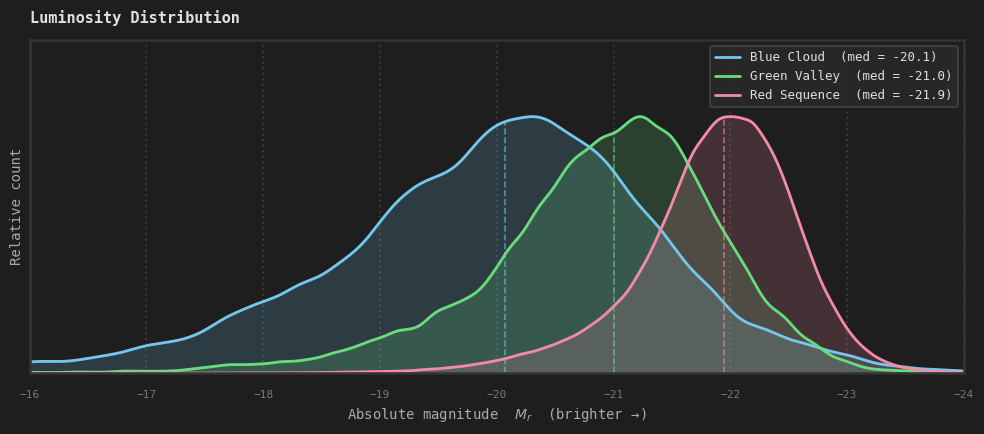

In [7]:
import matplotlib.pyplot as plt # Import plotting library

# Setup the plot
fig, ax = plt.subplots(figsize=(10, 4.5), facecolor="#1e1e1e")
ax.set_facecolor("#1e1e1e")

# Set an x-range for the KDE plot
x_range = np.linspace(-24, -16, 600)

for pop, color, label in [(blue, "#74c7ec", "Blue Cloud"), (green,  "#69db7c", "Green Valley"), (red,  "#f38ba8", "Red Sequence")]:
    vals = pop["M_r"].dropna().values # Drop NaN values and get the absolute magnitude array
    kde = gaussian_kde(vals, bw_method=0.08) # Create a KDE object with a specified bandwidth
    k = kde(x_range) / kde(x_range).max() # Normalise the KDE
    ax.fill_between(x_range, 0, k, color=color, alpha=0.18) # Fill the area under the KDE curve
    ax.plot(x_range, k, lw=2, color=color, label=f"{label}  (med = {np.median(vals):.1f})") # Plot the KDE curve and include the median in the label
    med = np.median(vals) # Find the median
    ax.vlines(med, 0, kde([med])[0]/kde(x_range).max(), color=color, lw=1.2, ls="--", alpha=0.6) # Add a vertical line at the median

# Final plot formatting
ax.set_xlim(-24, -16)
ax.set_ylim(0, 1.3)
ax.invert_xaxis() # So that brighter magnitudes are on the right
ax.set_yticks([])
ax.set_xlabel("Absolute magnitude  $M_r$  (brighter →)", color="#aaaaaa", fontsize=10)
ax.set_ylabel("Relative count", color="#aaaaaa", fontsize=10)
ax.set_title("Luminosity Distribution", color="#e0e0e0", fontsize=11, loc="left", pad=12)
ax.tick_params(colors="#777777", labelsize=8)
ax.grid(True, ls=":", alpha=0.12, color="#ffffff")
ax.legend(facecolor="#2a2a2a", edgecolor="#444444", labelcolor="#e0e0e0", fontsize=9)
for sp in ax.spines.values():
    sp.set_edgecolor("#333333")

# Show the plot
plt.tight_layout()
plt.show()

<div style="width: 1200px">

The first, most obvious thing to notice with this plot is that red sequence galaxies are systematically more luminous, and therefore more massive than blue cloud galaxies. Their distribution peaks at brighter (more negative) $M_r$ values, and extends to the most luminous objects in the sample. The Blue Cloud, on the other hand, peaks at fainter magnitudes, and green valley galaxies are there briefly in the middle.

While it may not be immediately obvious, this is one of the most fundamental results in galaxy evolution: **quenching is mass-dependent**. The most massive galaxies in the universe are almost all quenched. They converted their gas into stars early, and have been passive ever since. Comparatively, lower-mass galaxies are much more likely to still be forming stars.

The second thing you might notice is that because blue galaxies are systematically less bright, Malmquist bias means that it won't be detected as much by the SDSS telescope, which is exactly the problem we faced back in Part 2!

</div>

---

### The Size–Mass Relation

---


<div style="width: 1200px">

Now that we've looked at distances and magnitudes, the next thing we could look at is **sizes**. We've already touched on it in Part 3, when we looked at the Petrosian radius, but you may have noticed that we were hesitant to actually graph anything with the raw radius, and we only used derived quantities like the concentration index. This is because the Petrosian radius gives us a measurement in arcseconds (1/3600 of a degree), which is an **angular measurement**, not a physical one. This means that it can't be used by itself to compare the sizes of galaxies.

Take for example 2 objects. The moon and the sun. If you've looked up at the sky enough, you'll eventually find out that the moon and the sun appear pretty similar in size. In fact, this similarity in apparent size is the reason that we can get **solar eclipses** here on earth, where the moon appears to cover the sun. This metric of size is called **angular size**. In reality, we know that the sun is much bigger than the moon, it just appears the same size because **the moon is a lot closer to us**.

The moon is closer to us. That's the key piece of information. In order to find out how big the moon, or the sun, or a galaxy actually is, we need both it's angular size, and its distance from us!

</div>

<div style="width: 1200px">
<center>
<div style="width: 1000px">
<img src="images/solar_eclipse.png" width="450px"></img>
<img src="images/angular_size.png" width="475px"></img>

<i><b>LEFT</b>: Credit: Nicole Granucci, <b>RIGHT</b>: Credit: Haylam Yuen</i>
</div>
</center>
</div>

<div style="width: 1200px">

It turns out that we can compute the physical size of a galaxy from the Petrosian radius and the **angular diameter distance** like so:

$$r_{\text{phys}} = \theta \times d_A = \theta \times \frac{d_L}{(1+z)^2}$$

where $\theta$ is the angular size in radians (not degrees). This angular size can be easily found from the Petrosian radius. Also, you may have realised that we've actually snuck in a division by $(1+z)^2$ in the calculation. This is to convert our **luminosity distance** into **angular diameter distance**, which requires a slightly different interpretation of the expansion of the universe.

At this point many of you might be really confused - we're using 3 different notions of distance (angular diameter, comoving and luminosity distances), each with different values, and all for calculations to do with distance. And that's understandable. Here on Earth, you can measure the size of a cup, or the height of a person, and there will only be 1 correct answer. But when we look at galaxies through a telescope, we are seeing them as they were millions or billions of years ago. So, is the distance that we use the distance that light travelled to get to us? Or the distance that light would have to travel if we beamed it at this moment to the galaxy? Or the physical, coordinate distance right now? Because the universe is expanding, this answer changes, and each answer is useful in its own context, so astronomers just like to keep them all in their pocket, and simply select the best one for the job when they need it.

</div>

Anyways, let's introduce physical sizes to our SDSS subset:

In [9]:
# Calculate physical size in kpc from angular size and distance
d_A = galaxies["d_L_mpc"] / (1 + galaxies["redshift"])**2 # Angular diameter distance in Mpc
arcsec_to_rad = np.pi / (180*3600) # Convert arcseconds to radians
galaxies["r_phys_kpc"] = (galaxies["petroRad_r"] * arcsec_to_rad * d_A * 1e3) # Physical size in kpc

Then we have to recalculate the low redshift sample:

In [10]:
# Colour subsets
gal_lowz2 = galaxies[(galaxies["redshift"] > 0.0045) & (galaxies["redshift"] < 0.20) & (galaxies["M_r"] < -16) & (galaxies["r_phys_kpc"] < 150) & (galaxies["r_phys_kpc"] > 0.1)].copy()

blue = gal_lowz2[gal_lowz2["g_r"] < 0.58] # Blue Cloud
red  = gal_lowz2[gal_lowz2["g_r"] > 0.76] # Red Sequence
green  = gal_lowz2[(gal_lowz2["g_r"] >= 0.58) & (gal_lowz2["g_r"] <= 0.76)] # Green Valley

print(f"Physical size range: {gal_lowz2['r_phys_kpc'].min():.1f} to {gal_lowz2['r_phys_kpc'].max():.1f} kpc")

Physical size range: 0.4 to 141.5 kpc


Now, let's plot the physical sizes of galaxies against their masses (in this plot, we'll use the absolute magnitude as a proxy for mass):

/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


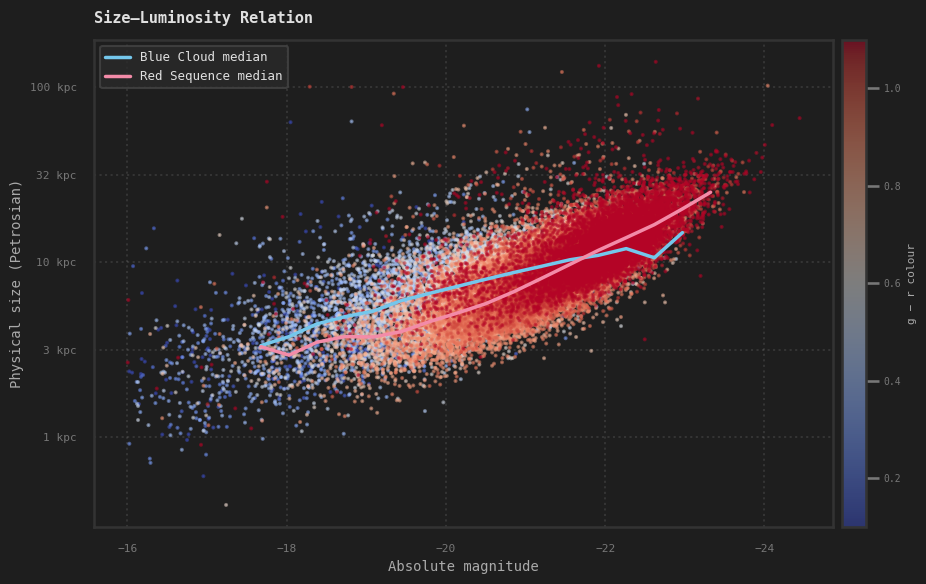

In [11]:
# Select a random sample for plotting
sample = gal_lowz2.sample(min(40000, len(gal_lowz)), random_state=67)

# Prepare data for scatter plot
x = sample["M_r"].values # Absolute magnitude in r-band
y = np.log10(sample["r_phys_kpc"].values) # Logarithm of physical size in kpc
c = sample["g_r"].values # Colour code by g-r colour index
idx = np.argsort(c); x,y,c = x[idx],y[idx],c[idx] # Sort by colour for better plotting

# Setup the plot
fig, ax = plt.subplots(figsize=(10, 6), facecolor="#1e1e1e")
ax.set_facecolor("#1e1e1e")

# Create the scatter plot
sc = ax.scatter(x, y, c=c, cmap="coolwarm", vmin=0.1, vmax=1.1, s=2, alpha=0.5, rasterized=True)

# Make the median size lines for each colour class
M_bins = np.linspace(-23.5, -17.5, 18) # Define bins for absolute magnitude
M_mids = 0.5*(M_bins[:-1]+M_bins[1:]) # Midpoints of the magnitude bins
for pop, color, label in [(blue, "#74c7ec", "Blue Cloud"), (red,  "#f38ba8", "Red Sequence")]: # Loop over colour classes
    meds = []
    for lo,hi in zip(M_bins[:-1], M_bins[1:]): # Loop over magnitude bins
        b = pop[(pop["M_r"]>=lo)&(pop["M_r"]<hi)]["r_phys_kpc"] # Select galaxies in the current magnitude bin and get their physical sizes
        meds.append(np.log10(np.median(b))) # Append the log of the median size to the medians list
    ax.plot(M_mids, meds, color=color, lw=2.5, label=f"{label} median", zorder=5) # Plot the median size lines

# Create the colourbar
cbar = plt.colorbar(sc, ax=ax, pad=0.01)
cbar.set_label("g − r colour", color="#aaaaaa", fontsize=8)
cbar.ax.yaxis.set_tick_params(color="#777777")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#777777", fontsize=7)
cbar.outline.set_edgecolor("#333333")

# Make it so that the y-axis labels are in kpc
yticks = [0, 0.5, 1, 1.5, 2]
ax.set_yticks(yticks)
ax.set_yticklabels([f"{10**y:.0f} kpc" for y in yticks], color="#777777", fontsize=8)

# Final plot formatting
ax.set_xlabel("Absolute magnitude", color="#aaaaaa", fontsize=10)
ax.set_ylabel("Physical size (Petrosian)", color="#aaaaaa", fontsize=10)
ax.set_title("Size–Luminosity Relation", color="#e0e0e0", fontsize=11, loc="left", pad=12)
ax.invert_xaxis() # So that brighter magnitudes are on the right
ax.tick_params(colors="#777777", labelsize=8)
ax.grid(True, ls=":", alpha=0.10, color="#ffffff")
ax.legend(facecolor="#2a2a2a", edgecolor="#444444", labelcolor="#e0e0e0", fontsize=9)
for sp in ax.spines.values():
    sp.set_edgecolor("#333333")

# Show the plot
plt.tight_layout()
plt.show()

<div style="width: 1200px">

So from the graph, we can see that more luminous galaxies are consistently physically larger, and the relationship holds across almost two orders of magnitude in size.

**At any fixed luminosity, blue star-forming galaxies are roughly 1.5–2× larger than red quenched galaxies**. This is direct evidence that quenching and structural transformation are physically linked, though, as we've seen previously, they do not always happen at the same time. Elliptical galaxies are not simply spirals that stopped forming stars, they have also undergone a physical compaction, likely through merging with other galaxies, which would cause a redistribution stellar matter from ordered rotation into random pressure-supported motion, making a big blob known as an elliptical galaxy.

</div>

---

### Mass-Dependent Quenching

---

<div style="width: 1200px">

To expand upon this, we can move to 

</div>

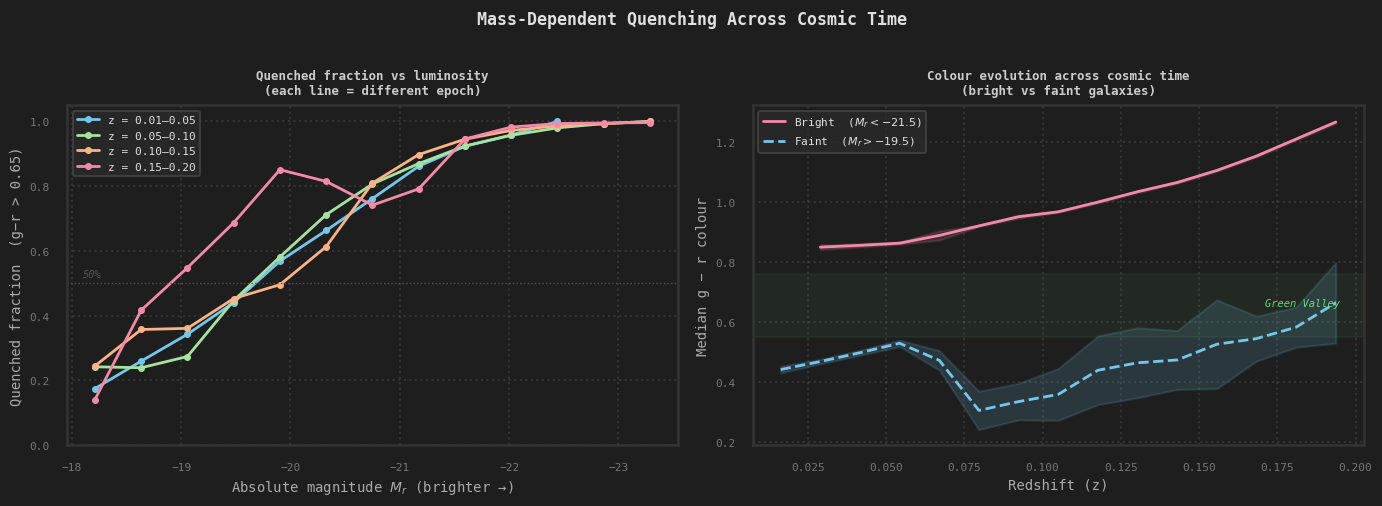

In [ ]:
# Setup the plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="#1e1e1e")
fig.suptitle("Mass-Dependent Quenching", color="#e0e0e0", fontsize=12, fontweight="bold", y=1.01)

# LEFT PLOT: Quenched fraction vs Absolute magnitudes
ax1 = axes[0]; ax1.set_facecolor("#1e1e1e")

# Define redshift slices (aka lookback times)
z_slices = [(0.01, 0.05, "#74c7ec", "z = 0.01–0.05"),
            (0.05, 0.10, "#a6e3a1", "z = 0.05–0.10"),
            (0.10, 0.15, "#fab387", "z = 0.10–0.15"),
            (0.15, 0.20, "#f38ba8", "z = 0.15–0.20")]
M_bins = np.linspace(-23.5, -18.0, 14) # Bins for absolute magnitude
M_mids = 0.5*(M_bins[:-1]+M_bins[1:]) # Midpoints of the magnitude bins

for z_lo, z_hi, color, label in z_slices: # Loop over redshift slices
    sl = galaxies[(galaxies["redshift"]>=z_lo) & (galaxies["redshift"]<z_hi) & (galaxies["M_r"].notna())] # Select galaxies in the current redshift slice with valid M_r values
    fq = []
    for lo, hi in zip(M_bins[:-1], M_bins[1:]): # Loop over magnitude bins
        b = sl[(sl["M_r"]>=lo) & (sl["M_r"]<hi)] # Select galaxies in the current magnitude bin
        fq.append((b["g_r"] > 0.65).sum() / len(b)) # Calculate the quenched fraction (g-r > 0.65) and append to the list

    ax1.plot(M_mids, fq, color=color, lw=2, marker="o", markersize=4, label=label) # Plot the quenched fraction vs magnitude for the current redshift slice

# Final plot formatting for the left plot
ax1.invert_xaxis() # So that brighter magnitudes are on the right
ax1.set_xlabel("Absolute magnitude", color="#aaaaaa", fontsize=10)
ax1.set_ylabel("Quenched fraction of galaxies (g−r > 0.65)", color="#aaaaaa", fontsize=10)
ax1.set_title("Quenched fraction vs luminosity", color="#cccccc", fontsize=9, pad=8)
ax1.set_ylim(0, 1.05)
ax1.axhline(0.5, color="#555555", lw=1, ls=":")
ax1.text(-18.1, 0.52, "50%", color="#555555", fontsize=7.5, style="italic")
ax1.tick_params(colors="#777777", labelsize=8)
ax1.grid(True, ls=":", alpha=0.10, color="#ffffff")
ax1.legend(facecolor="#2a2a2a", edgecolor="#444444", labelcolor="#e0e0e0", fontsize=8)
for sp in ax1.spines.values():
    sp.set_edgecolor("#333333")

# RIGHT PLOT: Median g-r vs Redshift for bright vs faint subsamples
ax2 = axes[1]; ax2.set_facecolor("#1e1e1e")

# Set up redshift bins for the right plot
z_bins = np.linspace(0.01, 0.20, 16)
z_mids = 0.5*(z_bins[:-1]+z_bins[1:])

# Loop over bright and faint subsamples defined by absolute magnitude cuts
for Mr_cut, color, label, ls in [(-21.5, "#f38ba8", "Bright  ($M_r < -21.5$)", "-"), (-19.5, "#74c7ec", "Faint  ($M_r > -19.5$)",  "--"),]:
    if Mr_cut < -20:
        sub = galaxies[galaxies["M_r"] < Mr_cut]
    else:
        sub = galaxies[galaxies["M_r"] > Mr_cut]
    meds, errs = [], []
    for lo, hi in zip(z_bins[:-1], z_bins[1:]):
        b = sub[(sub["redshift"]>=lo) & (sub["redshift"]<hi)]["g_r"].dropna()
        if len(b) < 30:
            meds.append(np.nan); errs.append(np.nan)
        else:
            meds.append(np.median(b))
            errs.append(b.std() / np.sqrt(len(b)))
    meds = np.array(meds); errs = np.array(errs)
    ax2.plot(z_mids, meds, color=color, lw=2, ls=ls, label=label)
    ax2.fill_between(z_mids, meds-errs, meds+errs,
                     color=color, alpha=0.15)

ax2.axhspan(0.55, 0.76, color="#69db7c", alpha=0.06)
ax2.text(0.195, 0.655, "Green Valley", color="#69db7c",
         fontsize=7.5, ha="right", style="italic")
ax2.set_xlabel("Redshift (z)", color="#aaaaaa", fontsize=10)
ax2.set_ylabel("Median g − r colour", color="#aaaaaa", fontsize=10)
ax2.set_title("Colour evolution across cosmic time\n(bright vs faint galaxies)",
              color="#cccccc", fontsize=9, pad=8)
ax2.tick_params(colors="#777777", labelsize=8)
ax2.grid(True, ls=":", alpha=0.10, color="#ffffff")
ax2.legend(facecolor="#2a2a2a", edgecolor="#444444",
           labelcolor="#e0e0e0", fontsize=8)
for sp in ax2.spines.values(): sp.set_edgecolor("#333333")

plt.tight_layout()
plt.show()

<div style="width: 1200px">

This is perhaps the most scientifically important plot in this notebook — it
directly addresses our central question: **what drives galaxy transformation?**

**Left panel — quenched fraction vs luminosity.** At every epoch (each coloured
line represents a different redshift slice, and therefore a different lookback
time), the quenched fraction rises steeply with luminosity. Faint, low-mass
galaxies are predominantly blue and star-forming; bright, massive galaxies are
predominantly red and quenched. This is **mass-dependent quenching** — the
probability that a galaxy has shut off its star formation is not random, it is
strongly coupled to how massive the galaxy is.

The vertical position of each line also carries information: if the lines shift
upward at lower redshift (lower z), it means a larger fraction of galaxies at any
given mass have quenched over time — the red sequence is growing. Conversely, if
the lines are nearly coincident, quenching happened early and the population has
not changed much within this redshift range.

**Right panel — colour evolution by mass.** Bright, massive galaxies (pink, solid
line) are consistently redder than faint galaxies (blue, dashed) at every
redshift in our sample. The shaded bands show the uncertainty on the median. Note
how the bright galaxy line sits well above the green valley throughout — massive
galaxies quenched a long time ago and have stayed red. The faint galaxy line sits
lower and shows more scatter, consistent with a population that is still actively
forming stars across a range of rates.

**The Malmquist caveat:** At $z > 0.12$, the faint galaxy sample becomes
increasingly incomplete — we only detect the brightest of the "faint" galaxies at
large distances. The apparent reddening of the faint line at high $z$ is therefore
partly real (fewer star-forming galaxies in the past) and partly a flux-limit
artefact. Disentangling these two effects requires volume corrections beyond the
scope of this project, but the qualitative picture — mass-dependent quenching,
with massive galaxies quenching first — is robust.

</div>

---

### The Luminosity–Size–Colour Cube

---

<div style="width: 1200px">

Now that we have explored three intrinsic physical properties for each galaxy: luminosity ($M_r$), physical size ($r_{\rm phys}$), and colour ($g-r$), we can plot all three together in a 2D diagram, using colour as the third axis. This is sometimes called the **fundamental plane of elliptical galaxies***.

If our analysis is correct, we would expect:

* Bright + large + blue → massive star-forming spirals
* Bright + compact + red → massive quenched ellipticals  
* Faint + small + blue → dwarf irregulars and small spirals
* Faint + small + red → dwarf ellipticals and spheroidals

**The classic plane consists of effective radius, average surface brightness and central velocity dispersion, but these are all proxies for, and relate to the metrics used in our plot*

</div>

In [12]:
sample3 = gal_lowz[
    (gal_lowz["r_phys_kpc"] > 0.5) & (gal_lowz["r_phys_kpc"] < 80) &
    (gal_lowz["M_r"] > -24) & (gal_lowz["M_r"] < -17)
].sample(min(35000, len(gal_lowz)), random_state=42)

x3 = sample3["M_r"].values
y3 = np.log10(sample3["r_phys_kpc"].values)
c3 = sample3["g_r"].clip(0.0, 1.2).values
idx3 = np.argsort(c3); x3, y3, c3 = x3[idx3], y3[idx3], c3[idx3]

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor="#1e1e1e")
fig.suptitle("Luminosity × Size × Colour — the three-dimensional portrait of galaxy evolution",
             color="#e0e0e0", fontsize=11, fontweight="bold", y=1.01)

yticks     = [0, 0.5, 1.0, 1.5, 2.0]
ytick_labs = [f"{10**y:.0f} kpc" for y in yticks]

# ── Left: scatter coloured by g-r ──────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#1e1e1e")

sc = ax1.scatter(x3, y3, c=c3, cmap="RdYlBu_r",
                 vmin=0.1, vmax=1.1, s=3, alpha=0.55, rasterized=True)

ap = dict(fontsize=8.5, bbox=dict(boxstyle="round,pad=0.4",
           fc="#0d0d14", ec="#333344", alpha=0.85))
ax1.text(-21.8, 1.72, "Massive quenched\nellipticals",
         color="#f38ba8", ha="center", **ap)
ax1.annotate("Star-forming spirals\n(bluer, smaller at\nfixed luminosity)",
    xy=(-19.5, 0.75), xytext=(-18.0, 1.35),
    color="#74c7ec", fontsize=8.5, ha="center",
    bbox=dict(boxstyle="round,pad=0.4", fc="#0d0d14", ec="#333344", alpha=0.85),
    arrowprops=dict(arrowstyle="-|>", color="#74c7ec", lw=1.2))

cbar1 = plt.colorbar(sc, ax=ax1, pad=0.02)
cbar1.set_label("g − r colour  (blue → red)", color="#aaaaaa", fontsize=8)
cbar1.ax.yaxis.set_tick_params(color="#777777")
plt.setp(cbar1.ax.yaxis.get_ticklabels(), color="#777777", fontsize=7)
cbar1.outline.set_edgecolor("#333333")

ax1.set_xlabel("Absolute magnitude  $M_r$  (brighter →)",
               color="#aaaaaa", fontsize=10)
ax1.set_ylabel("Physical size  $r_{\\rm phys}$", color="#aaaaaa", fontsize=10)
ax1.set_title("Individual galaxies — coloured by g−r",
              color="#cccccc", fontsize=9, pad=8)
ax1.invert_xaxis()
ax1.set_yticks(yticks)
ax1.set_yticklabels(ytick_labs, color="#777777", fontsize=8)
ax1.tick_params(colors="#777777", labelsize=8)
ax1.grid(True, ls=":", alpha=0.08, color="#ffffff")
for sp in ax1.spines.values(): sp.set_edgecolor("#333333")
ax1.text(-17.15, 0.08, "z < 0.20 sample",
         color="#555555", fontsize=7, ha="right", style="italic")

# ── Right: pcolormesh of mean g-r per bin ──────────────────
ax2 = axes[1]
ax2.set_facecolor("#1e1e1e")

# Bin the data — mean g-r per cell
M_bins  = np.linspace(-24, -17, 50)
r_bins  = np.linspace(0, 2.0, 40)
M_mids  = 0.5*(M_bins[:-1]+M_bins[1:])
r_mids  = 0.5*(r_bins[:-1]+r_bins[1:])

# Digitise
xi = np.digitize(x3, M_bins) - 1
yi = np.digitize(y3, r_bins) - 1
grid_sum   = np.full((len(r_bins)-1, len(M_bins)-1), np.nan)
grid_count = np.zeros_like(grid_sum)

for i, (xi_, yi_, ci_) in enumerate(zip(xi, yi, c3)):
    if 0 <= xi_ < grid_sum.shape[1] and 0 <= yi_ < grid_sum.shape[0]:
        if np.isnan(grid_sum[yi_, xi_]):
            grid_sum[yi_, xi_] = 0.0
        grid_sum[yi_, xi_]   += ci_
        grid_count[yi_, xi_] += 1

grid_mean = np.where(grid_count > 3, grid_sum / grid_count, np.nan)

pcm = ax2.pcolormesh(M_bins, r_bins, grid_mean,
                     cmap="RdYlBu_r", vmin=0.1, vmax=1.1,
                     shading="flat", rasterized=True)


cbar2 = plt.colorbar(pcm, ax=ax2, pad=0.02)
cbar2.set_label("Mean g − r per bin", color="#aaaaaa", fontsize=8)
cbar2.ax.yaxis.set_tick_params(color="#777777")
plt.setp(cbar2.ax.yaxis.get_ticklabels(), color="#777777", fontsize=7)
cbar2.outline.set_edgecolor("#333333")

ax2.set_xlabel("Absolute magnitude  $M_r$  (brighter →)",
               color="#aaaaaa", fontsize=10)
ax2.set_ylabel("Physical size  $r_{\\rm phys}$", color="#aaaaaa", fontsize=10)
ax2.set_title("Mean colour per bin",
              color="#cccccc", fontsize=9, pad=8)
ax2.invert_xaxis()
ax2.set_yticks(yticks)
ax2.set_yticklabels(ytick_labs, color="#777777", fontsize=8)
ax2.tick_params(colors="#777777", labelsize=8)
ax2.grid(True, ls=":", alpha=0.08, color="#ffffff")
for sp in ax2.spines.values(): sp.set_edgecolor("#333333")

plt.tight_layout()
plt.show()

KeyError: 'r_phys_kpc'

<div style="width: 1200px">

The diagonal cloud running from bottom-left (faint, small) to top-right (bright, large)
is the size–luminosity relation — more massive galaxies are physically larger. The colour
gradient running *across* this diagonal is the key finding: at any fixed luminosity,
**red galaxies tend to be larger than blue ones**, because the most massive objects in
the sample are overwhelmingly red ellipticals that have built up large stellar envelopes
through mergers.

The relative absence of large blue spirals reflects the same Malmquist bias we have
seen throughout — at the distances this sample covers, the flux limit preferentially
selects bright, massive, and therefore mostly red galaxies. Large star-forming spirals
do exist, but they are rarer at these masses, and our sample does not reach deep enough
to show the full blue population at the faint end.
</div>

---

### Interactive: The Surface Brightness Explorer

---

<div style="width: 1200px">

**Surface brightness** is the amount of light per unit area on the sky — it tells us not just how bright a galaxy is, but how spread out that light is. It connects size and luminosity:

$$\mu_{\rm eff} = M_r + 2.5\log_{10}(2\pi\, r_{50}^2) + C_{\rm offset}$$

where $r_{50}$ is the half-light radius in kpc and $C_{\rm offset}$ is a constant that converts to surface brightness units (mag arcsec⁻²). A low value of $\mu_{\rm eff}$ (bright) means light packed into a small area — typical of ellipticals. A high value means diffuse, spread-out light — typical of low-surface-brightness spirals.

Surface brightness is fascinating because it is **redshift-independent in physical units** but drops sharply with $(1+z)^4$ in observed units — the **Tolman surface brightness test**, which was one of the earliest observational tests of the expanding universe. We'll revisit this in a later notebook.

</div>

In [ ]:
import ipywidgets as widgets
from IPython.display import display as ipy_display

# Effective surface brightness proxy (mag/arcsec^2 equivalent)
# Using petroR50_r in arcsec (apparent) for simplicity
gal_lowz = gal_lowz.copy()
gal_lowz["mu_eff"] = (
    gal_lowz["petroMag_r"] +
    2.5 * np.log10(2 * np.pi * gal_lowz["petroR50_r"]**2)
)
gal_lowz = gal_lowz[
    (gal_lowz["mu_eff"] > 18) & (gal_lowz["mu_eff"] < 28)
]

def plot_surface_brightness(x_axis):
    fig, ax = plt.subplots(figsize=(10, 5), facecolor="#1e1e1e")
    ax.set_facecolor("#1e1e1e")

    s = gal_lowz.sample(min(25000, len(gal_lowz)), random_state=42)
    c = s["g_r"].clip(0.0, 1.2).values
    y = s["mu_eff"].values

    if x_axis == "Absolute magnitude M_r":
        x = s["M_r"].values
        xlabel = "Absolute magnitude $M_r$ (brighter →)"
        invert = True
    elif x_axis == "Physical size (kpc)":
        x = np.log10(s["r_phys_kpc"].clip(0.1,100).values)
        xlabel = "log₁₀(Physical size / kpc)"
        invert = False
    else:
        x = s["redshift"].values
        xlabel = "Redshift (z)"
        invert = False

    idx = np.argsort(c); x,y,c = x[idx],y[idx],c[idx]
    sc = ax.scatter(x, y, c=c, cmap="coolwarm_r", vmin=0.1, vmax=1.1,
                    s=1.5, alpha=0.45, rasterized=True)

    cbar = plt.colorbar(sc, ax=ax, pad=0.01)
    cbar.set_label("g − r colour", color="#aaaaaa", fontsize=8)
    cbar.ax.yaxis.set_tick_params(color="#777777")
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#777777", fontsize=7)
    cbar.outline.set_edgecolor("#333333")

    ax.set_xlabel(xlabel, color="#aaaaaa", fontsize=10)
    ax.set_ylabel("Effective surface brightness  $\\mu_{\\rm eff}$  (mag/arcsec²)",
                  color="#aaaaaa", fontsize=10)
    ax.set_title("Surface Brightness — how concentrated is the light?",
                 color="#e0e0e0", fontsize=11, loc="left", pad=12)
    ax.invert_yaxis()  # brighter (lower mag) at top
    if invert: ax.invert_xaxis()
    ax.tick_params(colors="#777777", labelsize=8)
    ax.grid(True, ls=":", alpha=0.10, color="#ffffff")
    for sp in ax.spines.values(): sp.set_edgecolor("#333333")
    plt.tight_layout()
    plt.show()

xax_w = widgets.ToggleButtons(
    options=["Absolute magnitude M_r", "Physical size (kpc)", "Redshift"],
    description="x-axis:",
    style={"description_width": "initial", "button_width": "160px"}
)
out3 = widgets.interactive_output(plot_surface_brightness, {"x_axis": xax_w})
ipy_display(widgets.VBox([xax_w], layout=widgets.Layout(padding="8px 0")), out3)

<div style="width: 1200px">

Switch between the three x-axis options:

* **vs $M_r$:** Brighter galaxies tend to have higher surface brightness — they pack more light into comparable areas. Red galaxies cluster toward the bright (low $\mu_{\rm eff}$) end.
* **vs physical size:** Larger galaxies tend to have lower surface brightness — their light is more spread out. This is the Kormendy relation for ellipticals (a tight sequence) and a looser version for spirals.
* **vs redshift:** The observed surface brightness should drop with $(1+z)^4$ for a standard expanding universe — look for evidence of this dimming at higher $z$ values.

</div>

---

### What We've Learned

---

<div style="width: 1200px">

This notebook has moved us from appearance to physical reality — converting redshifts into distances, apparent brightnesses into luminosities, and angular sizes into physical extents. The picture that emerges is consistent and compelling:

* **Quenching is mass-dependent.** The most massive, luminous galaxies are almost all red and quenched. Lower-mass galaxies are far more likely to still be forming stars. Whatever mechanism drives quenching, it preferentially affects the most massive systems.

* **Spirals and ellipticals follow different size–luminosity tracks.** At any given luminosity, blue spirals are physically larger than red ellipticals. This size offset is a direct signature of their different formation histories — discs grow by accreting gas; ellipticals form through mergers.

* **Surface brightness encodes the history of a galaxy's mass assembly.** Compact, high-surface-brightness systems have concentrated their stellar mass efficiently; diffuse, low-surface-brightness systems have spread it across large discs.

* **The flux limit distorts our view of galaxy evolution.** At higher redshift, only the brightest, typically reddest galaxies are detectable — meaning any attempt to trace how galaxy populations change with cosmic time must account carefully for what we cannot see.

In the next notebook, we build on all of this — combining colour, structure, luminosity, and size into a unified machine learning framework that attempts to place each galaxy at a specific stage in its evolutionary lifecycle.

</div>